## FISPACT II legacy output

F4Enix wraps [pypact](https://github.com/fispact/pypact) to provide some higher level routines and to complement some of the missing feature.

## Parsing of pathways

```{eval-rst}
The complete API can be found at :py:class:`f4enix.output.fispact_legacy_out.PathwayCollection`
```

Unfortunately, reaction pathways are not supported yet in pypact, so a parser has been built directly in F4Enix

In [1]:
from f4enix.output.fispact_legacy_out import PathwayCollection
from pprint import pprint # just to print in a nicer way

pathways_collection = PathwayCollection.from_file('testSS.out')
pprint(pathways_collection.pathways)  # print the pathways in the collection

c:\F4EMiniforge3\envs\dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Pathway(parent=Mn55,
         daughter=Mn56,
         perc=43.807,
         reactions=['(n,g)'],
         intermediates=None),
 Pathway(parent=Fe56,
         daughter=Mn56,
         perc=56.135,
         reactions=['(n,p)'],
         intermediates=None),
 Pathway(parent=Cr52,
         daughter=V52,
         perc=96.532,
         reactions=['(n,p)'],
         intermediates=None),
 Pathway(parent=Mn55,
         daughter=V52,
         perc=2.86,
         reactions=['(n,a)'],
         intermediates=None),
 Pathway(parent=Si28,
         daughter=Al28,
         perc=96.924,
         reactions=['(n,p)'],
         intermediates=None),
 Pathway(parent=P31,
         daughter=Al28,
         perc=2.384,
         reactions=['(n,a)'],
         intermediates=None),
 Pathway(parent=Ni58,
         daughter=Co58,
         perc=54.559,
         reactions=['(n,p)'],
         intermediates=None),
 Pathway(parent=Ni58,
         daughter=Co58,
         perc=44.714,
         reactions=['(n,p)', '(IT)'],
    

In [2]:
# as it can see above, each pathway is represented as a dataclass that have
# different attributes that can be accessed directly
pathway = pathways_collection.pathways[13]
# a handy str method is provided to get a compact description of the pathway
print(pathway)
print(pathway.is_multistep())  # isomeric transitions are not considered as steps
print(pathway.reduce())  # isomeric transitions can be compressed

Co59 -(n,g)-> Co60m -(IT)-> Co60
False
Co59 -(n,g)-> Co60


In [3]:
# Zaid data is contanied in the FispactZaid dataclass
zaid = pathway.parent
zaid

Co59

In [4]:
# Finally, it is also possible to get a dataframe summarizing all the pathways
pathways_collection.to_dataframe().iloc[20:30]

Parent Intermediates       Reactions
Daughter % contribution                                     
Fe55     7.123            Fe54            []         [(n,g)]
         86.318           Fe56            []        [(n,2n)]
         6.119            Ni58            []         [(n,a)]
Fe59     10.285           Ni62            []         [(n,a)]
         3.422            Co59            []         [(n,p)]
         86.129           Fe58            []         [(n,g)]
Co57     96.742           Ni58            []        [(n,np)]
         3.067            Ni58        [Ni57]  [(n,2n), (b+)]
Co58     44.714           Ni58       [Co58m]   [(n,p), (IT)]
         54.559           Ni58            []         [(n,p)]

## Parsing of the output file at large

When parsing a FISPACT output the code requires to specify labels to be associated with the different cooling times after shutdown. No internal check is performed to assert that the number of labels provided corresponds to the number of cooling times defined in the FISPACT run. Simply the last N times will be selected where N is the number of provided labels.

In [5]:
from f4enix.output.fispact_legacy_out import FispactOutput

cooling_time_labels = ['1d', '11.6d', '30d', '180d', '1y', '10y']
outp = FispactOutput('testSS.out', cooling_time_labels)
# the original pypact TimeStep objects can be found in the inventory_data attribute
print(type(outp.inventory_data[0]))

<class 'pypact.output.timestep.TimeStep'>


Cooling times in seconds are extracted from the output

In [6]:
outp.cooling_times

[86400.0, 1000000.0, 2592000.0, 15552000.0, 31558000.0, 315578000.0]

If pathway uncertainty was activated during the fispact run, this can be retrieved

In [7]:
outp.uncertainty

,max uncertainty [%],min uncertainty [%]
quantity,,
Activity,0.0,0.0
Beta Heat Prod,0.0,0.0
Gamma Dose Rate,0.0,0.0
Gamma Heat Prod,0.0,0.0
Heat Production,0.0,0.0
Ingestion Dose,NaN,NaN
Inhalation Dose,NaN,NaN


### Main dataframes

The main attributes of the object are the SDDR, activity and decay heat global dataframe and the pathways collection

In [8]:
outp.sddr.head()

,element,isotope,state,dose,cooling time,isotope % dose,Cumulative dose sum
77,Co,58,,0.020570,1d,57.625344,57.625344
65,Mn,54,,0.007403,1d,20.738961,78.364305
80,Co,60,,0.004508,1d,12.628831,90.993136
154,Ta,182,,0.001325,1d,3.711890,94.705026
82,Ni,57,,0.000397,1d,1.111886,95.816912


In [9]:
outp.decay_heat.head()

,element,isotope,state,heat,alpha_heat,beta_heat,gamma_heat,cooling time,isotope % heat,Cumulative heat sum
77,Co,58,,1.359000e-08,0.0,4.614000e-10,1.313000e-08,1d,55.998079,55.998079
65,Mn,54,,4.590000e-09,0.0,2.200000e-11,4.568000e-09,1d,18.913259,74.911338
80,Co,60,,2.619000e-09,0.0,9.747000e-11,2.522000e-09,1d,10.791683,85.703021
154,Ta,182,,9.450000e-10,0.0,1.363000e-10,8.087000e-10,1d,3.893906,89.596927
76,Co,57,,6.446000e-10,0.0,8.216000e-11,5.624000e-10,1d,2.656097,92.253024


In [10]:
outp.activity.head() 

,element,isotope,state,activity,cooling time,isotope % activity,Cumulative activity sum
69,Fe,55,,104700000.0,1d,31.633577,31.633577
77,Co,58,,83930000.0,1d,25.358225,56.991802
59,Cr,51,,44070000.0,1d,13.315108,70.306910
65,Mn,54,,34100000.0,1d,10.302817,80.609727
76,Co,57,,28030000.0,1d,8.468856,89.078583


In [11]:
outp.pathways_collection

A common task when running an activation study in preparation of a D1S calculation is to identify what are the main decay pathways that should be tracked during the simulation.The output objects allows to build a pandas dataframe of the contact dose (and pathways) at specific cooling times.

In [12]:
df = outp.filter_by_cum_dose(
    perc=95, # cap dose at 95% of the total dose
    label='11.6d', # the label of the cooling time to filter by
    add_pathways=True) # include the pathways in the output

df.set_index(['element', 'isotope', 'state'])

dose cooling time  isotope % dose  \
element isotope state                                          
Co      58             0.018560        11.6d       57.414388   
                       0.018560        11.6d       57.414388   
Mn      54             0.007231        11.6d       22.368720   
                       0.007231        11.6d       22.368720   
Co      60             0.004490        11.6d       13.889580   
Ta      182            0.001243        11.6d        3.845155   
Co      60             0.004490        11.6d       13.889580   
                       0.004490        11.6d       13.889580   
                       0.004490        11.6d       13.889580   

                       Cumulative dose sum                           pathway  \
element isotope state                                                          
Co      58                       57.414388                Ni58 -(n,p)-> Co58   
                                 57.414388  Ni58 -(n,p)-> Co58m -(IT)-> Co58   
Mn      54                       79.783108                Fe54 -(n,p)-> Mn54   
                                 79.783108               Mn55 -(n,2n)-> Mn54   
Co      60                       93.672688  Co59 -(n,g)-> Co60m -(IT)-> Co60   
Ta      182                      97.517844              Ta181 -(n,g)-> Ta182   
Co      60                       93.672688                Co59 -(n,g)-> Co60   
                                 93.672688  Ni60 -(n,p)-> Co60m -(IT)-> Co60   
                                 93.672688                Ni60 -(n,p)-> Co60   

                       pathway % dose  
element isotope state                  
Co      58                  31.324716  
                            25.672270  
Mn      54                  16.870041  
                             5.453494  
Co      60                   4.712734  
Ta      182                  3.822469  
Co      60                   3.766298  
                             3.030706  
                             2.235528

Similarly, it is possible to filter also for decay heat contributors. Alpha, Beta and gamma heat columns refer to the daughter isotope, not to the specific pathway.

In [13]:
df = outp.filter_by_cum_heating(
    perc=95, # cap heat at 95% of the total heat
    label='1y', # the label of the cooling time to filter by
    add_pathways=True) # include the pathways in the output
df.set_index(['element', 'isotope', 'state'])

heat  alpha_heat     beta_heat    gamma_heat  \
element isotope state                                                         
Mn      54             2.044000e-09         0.0  9.798000e-12  2.034000e-09   
Co      60             2.297000e-09         0.0  8.549000e-11  2.212000e-09   
                       2.297000e-09         0.0  8.549000e-11  2.212000e-09   
                       2.297000e-09         0.0  8.549000e-11  2.212000e-09   
Mn      54             2.044000e-09         0.0  9.798000e-12  2.034000e-09   
Co      60             2.297000e-09         0.0  8.549000e-11  2.212000e-09   
        57             2.546000e-10         0.0  3.245000e-11  2.222000e-10   
        58             3.837000e-10         0.0  1.303000e-11  3.707000e-10   
                       3.837000e-10         0.0  1.303000e-11  3.707000e-10   
        57             2.546000e-10         0.0  3.245000e-11  2.222000e-10   

                      cooling time  isotope % heat  Cumulative heat sum  \
element isotope state                                                     
Mn      54                      1y       39.607393            84.117266   
Co      60                      1y       44.509873            44.509873   
                                1y       44.509873            44.509873   
                                1y       44.509873            44.509873   
Mn      54                      1y       39.607393            84.117266   
Co      60                      1y       44.509873            44.509873   
        57                      1y        4.933484            96.485856   
        58                      1y        7.435106            91.552372   
                                1y        7.435106            91.552372   
        57                      1y        4.933484            96.485856   

                                                pathway  pathway % heat  
element isotope state                                                    
Mn      54                           Fe54 -(n,p)-> Mn54       29.871103  
Co      60             Co59 -(n,g)-> Co60m -(IT)-> Co60       15.102200  
                                     Co59 -(n,g)-> Co60       12.069297  
                       Ni60 -(n,p)-> Co60m -(IT)-> Co60        9.712054  
Mn      54                          Mn55 -(n,2n)-> Mn54        9.656282  
Co      60                           Ni60 -(n,p)-> Co60        7.163864  
        57                          Ni58 -(n,np)-> Co57        4.772752  
        58                           Ni58 -(n,p)-> Co58        4.056519  
                       Ni58 -(n,p)-> Co58m -(IT)-> Co58        3.324533  
        57             Ni58 -(n,2n)-> Ni57 -(b+)-> Co57        0.151310

### Handy plots

The objects also provides handy plotter methods to observe the evolution in time of a certain quantity. As en example, below we can see the evolution of the SDDR in time for each isotope in the inventory. The number of isotopes is cut by the percentage threshold, in order to avoid overcrowded plots. The same type of plots can be obtained for heating and activity.

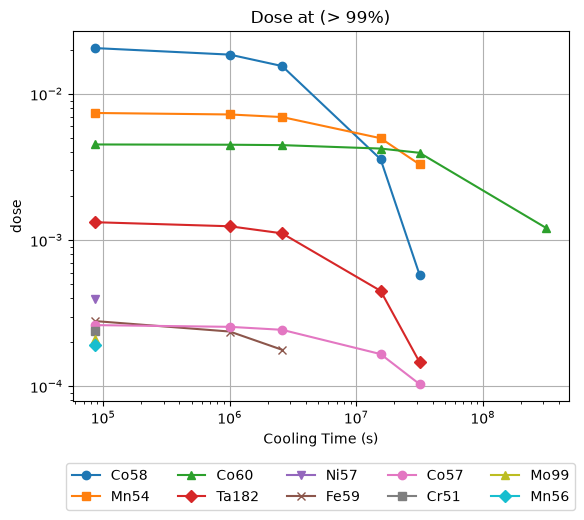

In [14]:
# you can customize the plot as preferred 
fig, ax = outp.plot_trend("dose", 99)